20260614
## Linear Regression
to predict continuous data.
straight line y = mx + C
y = prediction data
m = slope/coefficient (b1) -> covariance(x,y)/variance(x)
x = actual data
c = y-intercept (b0) -> constant

1. simple linear regression:
   - one feature one target
   - y = b0 + b1x1
2. multiple linear regression:
 - multiple feature one target
  - y = b0+b1x1+b2x2 + ....... + bnxn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("Real estate.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
cor = df.corr()

<Axes: >

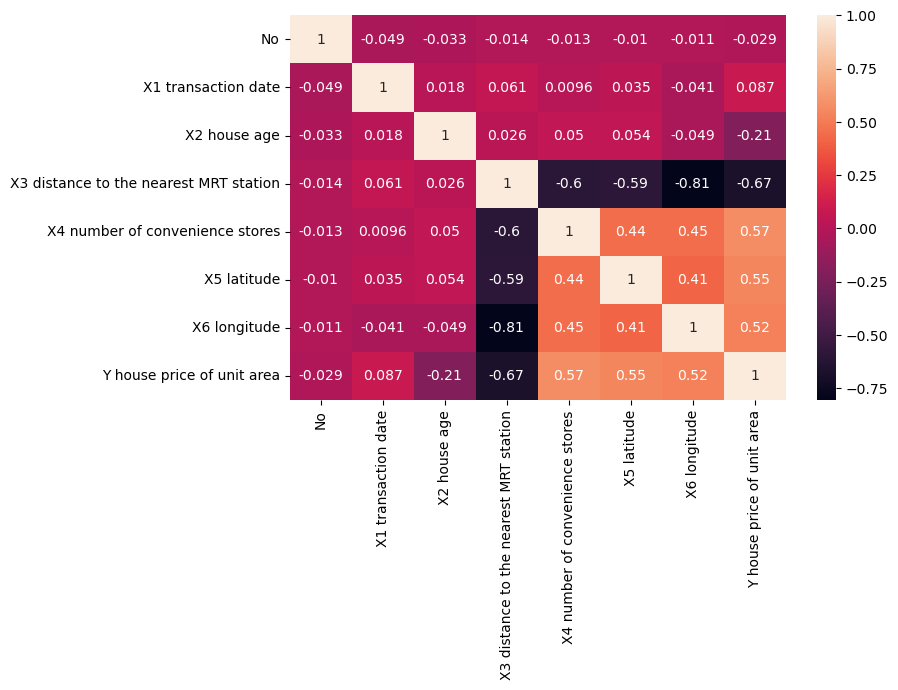

In [7]:
plt.figure(figsize=(8,5))
sns.heatmap(cor, annot=True)

In [8]:
# feature always must be multi dimension
# target always must be one dimension

In [9]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='str')

In [10]:
feature= ['X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
target = 'Y house price of unit area'

In [13]:
X =df[feature]
Y=df[target]

In [14]:
#Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,test_size = 0.2,random_state=42
)

In [15]:
scaler = StandardScaler()

In [16]:
#fit_transform -> feature training -> fit(Learning) transform(Implement)
#transform (implementation) -> feature testing
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

#### Linear Regression Model

In [17]:
model = LinearRegression()

In [18]:
# Training model
model.fit(X_train_scale,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 6)","[[ 1.53,-3.06,-5.79, 3.22, 2.86,-0.44]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[38.39]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[29.59,18.43,18.14,14.36,13.51, 7.3 ]"


In [19]:
# testing model
Y_pred = model.predict(X_test_scale)

In [20]:
Y_pred

array([[47.88625422],
       [41.16404556],
       [44.27301439],
       [40.19761542],
       [27.51326511],
       [45.10953115],
       [44.63293274],
       [46.36346234],
       [23.62063133],
       [54.33444894],
       [34.07416461],
       [36.54533193],
       [37.55154254],
       [23.2794052 ],
       [35.26614165],
       [34.38327747],
       [43.35633504],
       [45.40740539],
       [30.07083159],
       [44.09191493],
       [ 0.73505984],
       [34.99271686],
       [48.22735154],
       [45.48646485],
       [11.5995282 ],
       [39.69783664],
       [12.71276251],
       [42.91282893],
       [34.93451401],
       [37.27964515],
       [13.17842185],
       [40.12708486],
       [35.21883505],
       [27.71588924],
       [46.40090931],
       [31.21941994],
       [50.90046891],
       [14.07339433],
       [49.05344276],
       [40.0538446 ],
       [38.24588962],
       [40.63256441],
       [47.01634759],
       [37.65598977],
       [39.85801839],
       [46